In [1]:
!pip install ta
!pip install lightgbm

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29482 sha256=d7698ef8328c92c0cc372a191f9037fa0dcd94431aca2a8549e887f5e3338c66
  Stored in directory: /root/.cache/pip/wheels/e3/3a/ee/4955a26c90a4b7deb6d725dc8ec7b8604a7aef44e43a2e8af7
Successfully built ta


TA-Lib not available. Using manual technical indicators.
ETH/USDT 8h Log-Return Prediction System

Monitoring API Status...
----------------------------------------
Fetching current ETH price from DIA API...
Current ETH price from DIA: $2420.2637
Price timestamp: 2026-09-16 11:49:59+00:00
DIA API: Working - ETH Price: $2420.2637
   Timestamp: 2026-09-16 11:49:59+00:00
Fetching ETH/USDT training data from Tiingo API...
Date range: 2026-09-09 to 2026-09-16
Frequency: 1hour
Successfully loaded 160 data points from Tiingo
Last data timestamp: 2026-09-16 00:00:00+00:00
Date range: 2026-09-09 01:00:00+00:00 to 2026-09-15 16:00:00+00:00
Price range: $2406.95 to $2629.42
Tiingo API: Working - 160 data points
Date range: 2026-09-09 01:00:00+00:00 to 2026-09-15 16:00:00+00:00
----------------------------------------

Starting full pipeline execution...
ETH/USDT 8h LOG-RETURN PREDICTION PIPELINE
Training: Tiingo API | Current Price: DIA API
Target: ln(new_price / current_price) at 8h



1. Fetchi

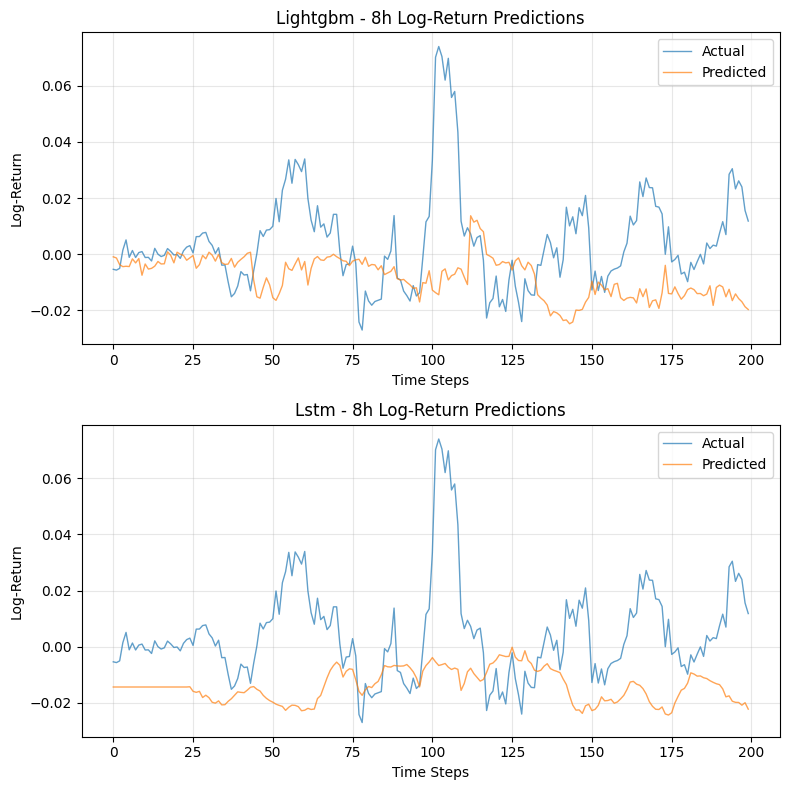


GENERATING 8h ETH/USDT LOG-RETURN PREDICTION
Fetching current real-time price from DIA API...
Fetching current ETH price from DIA API...
Current ETH price from DIA: $2421.8175
Price timestamp: 2026-09-16 11:51:59+00:00
Fetching recent training data from Tiingo...
Fetching ETH/USDT training data from Tiingo API...
Date range: 2026-07-18 to 2026-09-16
Frequency: 1hour
Successfully loaded 1432 data points from Tiingo
Last data timestamp: 2026-09-16 00:00:00+00:00
Date range: 2026-07-18 01:00:00+00:00 to 2026-09-15 16:00:00+00:00
Price range: $1835.16 to $2629.42

8h ETH/USDT LOG-RETURN PREDICTION
Prediction Timestamp: 2026-09-16 11:51:59+00:00
Model Used: LIGHTGBM
Horizon: 8h
--------------------------------------------------------------------------------
 Horizon | Change (%) |   Log Return
--------------------------------------------------------------------------------
      8h |     +0.50 |   +0.004972
Volatility (Last 100h): 0.0068

Pipeline executed successfully
Best Model: LIGHTGBM

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import warnings
import requests
import json
from datetime import datetime, timedelta
warnings.filterwarnings('ignore')

PREDICTION_HORIZON_HOURS = 8
HORIZON_KEY = f'{PREDICTION_HORIZON_HOURS}h'

try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False
    print("PyTorch not available. Using sklearn models only.")

try:
    import talib
    TALIB_AVAILABLE = True
except ImportError:
    TALIB_AVAILABLE = False
    print("TA-Lib not available. Using manual technical indicators.")

try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False
    print("LightGBM not available. Install with: pip install lightgbm")

class ZPTAELoss:
    """
    Z Power-Tanh Absolute Error Loss Function
    As specified in Allora competition requirements
    """

    @staticmethod
    def power_tanh(x, alpha=0.25, beta=2):
        """Power-tanh transformation"""
        return x / (1 + np.abs(x)**beta)**((1 - alpha) / beta)

    @staticmethod
    def loss_zptae(y_true, y_pred, sigma, mean=0, alpha=0.25, beta=2, gamma=4, penalty_norm=0.01):
        """
        Z power-tanh absolute error loss

        Args:
            y_true: Ground truth log-returns
            y_pred: Predicted log-returns
            sigma: Standard deviation of last 100 ground truth log-returns
            mean: Mean (default 0 for log-returns)
            alpha, beta, gamma, penalty_norm: Loss hyperparameters
        """
        # Standardize
        z_true = (y_true - mean) / sigma
        z_pred = (y_pred - mean) / sigma

        # Apply power-tanh transformation
        pt_true = ZPTAELoss.power_tanh(z_true, alpha=alpha, beta=beta)
        pt_pred = ZPTAELoss.power_tanh(z_pred, alpha=alpha, beta=beta)

        # Calculate loss components
        main_term = np.abs(pt_pred - pt_true)
        penalty_term = (penalty_norm * np.abs(z_pred - z_true))**gamma

        return main_term + penalty_term

class DataIngestion:
    """
    Comprehensive data ingestion class handling both Tiingo and DIA APIs
    """

    def __init__(self, tiingo_api_key='f1ce7fb13ab049fff2477baf20c893b59b5add8e'):
        self.tiingo_api_key = tiingo_api_key
        self.tiingo_base_url = 'https://api.tiingo.com/tiingo/crypto/prices'
        self.dia_base_url = 'https://api.diadata.org/v1/assetQuotation/Ethereum/0x0000000000000000000000000000000000000000'
        self.headers = {
            'Content-Type': 'application/json',
            'Authorization': f'Token {tiingo_api_key}'
        }
        self.data = None
        self.last_data_timestamp = None
        self.current_time = datetime.now()

    def fetch_current_price_from_dia(self):
        """
        Fetch current ETH price from DIA API
        Returns current price and timestamp
        """
        try:
            print("Fetching current ETH price from DIA API...")
            response = requests.get(self.dia_base_url, timeout=10)

            if response.status_code != 200:
                print(f"DIA API request failed with status code: {response.status_code}")
                return None, None

            data = response.json()

            current_price = data['Price']
            timestamp = pd.to_datetime(data['Time'])

            print(f"Current ETH price from DIA: ${current_price:.4f}")
            print(f"Price timestamp: {timestamp}")

            return current_price, timestamp

        except requests.exceptions.RequestException as e:
            print(f"Network error fetching DIA data: {e}")
            return None, None
        except Exception as e:
            print(f"Error parsing DIA data: {e}")
            return None, None

    def fetch_eth_training_data(self, days_back=730, resample_freq='1hour'):
        """
        Fetch ETH/USDT historical training data from Tiingo API
        """
        try:
            # Calculate date range
            end_date = datetime.now()
            start_date = end_date - timedelta(days=days_back)

            # Format dates for API
            start_date_str = start_date.strftime('%Y-%m-%d')
            end_date_str = end_date.strftime('%Y-%m-%d')

            print(f"Fetching ETH/USDT training data from Tiingo API...")
            print(f"Date range: {start_date_str} to {end_date_str}")
            print(f"Frequency: {resample_freq}")

            # Prepare API parameters
            params = {
                'tickers': 'ethusd',
                'startDate': start_date_str,
                'endDate': end_date_str,
                'resampleFreq': resample_freq
            }

            # Make API request
            response = requests.get(self.tiingo_base_url, headers=self.headers, params=params)

            if response.status_code != 200:
                print(f"Tiingo API request failed with status code: {response.status_code}")
                print(f"Response: {response.text}")
                return self._generate_synthetic_data()

            # Parse response
            data_json = response.json()

            if not data_json:
                print("No data returned from Tiingo API")
                return self._generate_synthetic_data()

            # Extract ETH/USDT data
            eth_data = data_json[0]['priceData'] if isinstance(data_json, list) else data_json['priceData']

            if not eth_data:
                print("No price data found for ETH/USDT")
                return self._generate_synthetic_data()

            # Convert to DataFrame
            df_data = []
            for point in eth_data:
                df_data.append({
                    'Date': pd.to_datetime(point['date']),
                    'Open': point['open'],
                    'High': point['high'],
                    'Low': point['low'],
                    'Close': point['close'],
                    'Volume': point['volume']
                })

            data = pd.DataFrame(df_data)
            data.set_index('Date', inplace=True)
            data.sort_index(inplace=True)

            # Clean data
            data = data.dropna()

            if data.empty:
                raise ValueError("No valid data after cleaning")

            # Store metadata
            self.last_data_timestamp = data.index[-1]
            self.current_time = datetime.now()

            # Calculate traditional log returns for training
            data['traditional_log_return'] = np.log(data['Close'] / data['Close'].shift(1))

            # Create target for the forecast horizon only
            data[f'log_return_{HORIZON_KEY}'] = data['traditional_log_return'].shift(-PREDICTION_HORIZON_HOURS)

            self.data = data.dropna()
            print(f"Successfully loaded {len(self.data)} data points from Tiingo")

            # Display summary
            print(f"Last data timestamp: {self.last_data_timestamp}")
            print(f"Date range: {self.data.index.min()} to {self.data.index.max()}")
            print(f"Price range: ${self.data['Close'].min():.2f} to ${self.data['Close'].max():.2f}")

            return self.data

        except requests.exceptions.RequestException as e:
            print(f"Network error fetching training data: {e}")
            return self._generate_synthetic_data()
        except Exception as e:
            print(f"Unexpected error fetching training data: {e}")
            return self._generate_synthetic_data()

class FeatureEngineering:
    """
    Comprehensive feature engineering for time series prediction
    """

    def __init__(self, lookback_windows=None):
        if lookback_windows is None:
            lookback_windows = [PREDICTION_HORIZON_HOURS, 12, 24, 48, 96, 168]
        self.lookback_windows = lookback_windows
        self.scaler = RobustScaler()
        self.feature_columns = []

    def create_features(self, data):
        """
        Create comprehensive feature set for ETH price prediction
        """
        df = data.copy()

        # 1. Lagged returns (key predictors)
        for lag in sorted(set([1, 2, 3, 4, PREDICTION_HORIZON_HOURS, 12, 24, 48, 72, 96, 168])):
            df[f'ret_lag_{lag}'] = df['traditional_log_return'].shift(lag)

        # Horizon-aligned momentum: strongest directional features for 8h-ahead
        for window in sorted(set([4, PREDICTION_HORIZON_HOURS, 12, 24, 48])):
            df[f'ret_sum_{window}h'] = df['traditional_log_return'].rolling(window).sum()
            df[f'ret_sum_sign_{window}h'] = np.sign(df[f'ret_sum_{window}h'])

        # 2. Rolling volatility measures
        for window in self.lookback_windows:
            df[f'vol_std_{window}h'] = df['traditional_log_return'].rolling(window).std()
            df[f'vol_ewma_{window}h'] = df['traditional_log_return'].ewm(halflife=window/2).std()
            df[f'realized_vol_{window}h'] = np.sqrt(
                df['traditional_log_return'].rolling(window).apply(lambda x: np.sum(x**2))
            )

        # 3. Moving averages and momentum
        for window in self.lookback_windows:
            df[f'sma_ret_{window}h'] = df['traditional_log_return'].rolling(window).mean()
            df[f'ema_ret_{window}h'] = df['traditional_log_return'].ewm(span=window).mean()

        # 4. Price-based technical indicators
        for window in [24, 48, 168]:
            # Price moving averages
            df[f'price_sma_{window}h'] = df['Close'].rolling(window).mean()
            df[f'price_ratio_{window}h'] = df['Close'] / df[f'price_sma_{window}h']

            # High/Low ratios
            df[f'hl_ratio_{window}h'] = df['High'].rolling(window).max() / df['Low'].rolling(window).min()

        # 5. Technical indicators
        if TALIB_AVAILABLE:
            df = self._add_talib_features(df)
        else:
            df = self._add_manual_technical_features(df)

        # 6. Market microstructure features
        df['bid_ask_spread'] = (df['High'] - df['Low']) / df['Close']
        df['volume_price_trend'] = df['Volume'] * df['traditional_log_return']

        # Volume-based features
        for window in [24, 48]:
            df[f'volume_sma_{window}h'] = df['Volume'].rolling(window).mean()
            df[f'volume_ratio_{window}h'] = df['Volume'] / df[f'volume_sma_{window}h']

        # 7. Cross-sectional rankings
        df['ret_rank_24h'] = df['traditional_log_return'].rolling(24).rank(pct=True)
        df['vol_rank_24h'] = df['vol_std_24h'].rolling(168).rank(pct=True)

        # 8. Regime indicators
        df['high_vol_regime'] = (df['vol_std_24h'] > df['vol_std_24h'].rolling(168).quantile(0.75)).astype(int)
        df['trend_strength'] = np.abs(df['sma_ret_24h'])

        # 9. Time-based features
        df['hour'] = df.index.hour
        df['day_of_week'] = df.index.dayofweek
        df['is_weekend'] = (df.index.dayofweek >= 5).astype(int)
        df['is_night'] = ((df.index.hour >= 22) | (df.index.hour <= 6)).astype(int)

        # Cyclical encoding
        df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
        df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
        df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
        df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

        return df.dropna()

    def _add_manual_technical_features(self, df):
        """Manual implementation of key technical indicators"""
        # RSI
        for window in [14, 24]:
            delta = df['Close'].diff()
            gain = delta.where(delta > 0, 0).rolling(window).mean()
            loss = (-delta.where(delta < 0, 0)).rolling(window).mean()
            rs = gain / loss
            df[f'rsi_{window}h'] = 100 - (100 / (1 + rs))

        # Bollinger Bands
        window = 48
        sma = df['Close'].rolling(window).mean()
        std = df['Close'].rolling(window).std()
        df['bb_upper'] = sma + 2 * std
        df['bb_lower'] = sma - 2 * std
        df['bb_position'] = (df['Close'] - df['bb_lower']) / (df['bb_upper'] - df['bb_lower'])

        # MACD
        ema_12 = df['Close'].ewm(span=12).mean()
        ema_26 = df['Close'].ewm(span=26).mean()
        df['macd'] = ema_12 - ema_26
        df['macd_signal'] = df['macd'].ewm(span=9).mean()
        df['macd_histogram'] = df['macd'] - df['macd_signal']

        return df

    def _add_talib_features(self, df):
        """Add TA-Lib technical indicators"""
        close_prices = df['Close'].values
        high_prices = df['High'].values
        low_prices = df['Low'].values
        volume = df['Volume'].values

        # RSI
        df['rsi_14h'] = talib.RSI(close_prices, timeperiod=14)
        df['rsi_24h'] = talib.RSI(close_prices, timeperiod=24)

        # MACD
        macd, macd_signal, macd_hist = talib.MACD(close_prices)
        df['macd'] = macd
        df['macd_signal'] = macd_signal
        df['macd_histogram'] = macd_hist

        # Stochastic
        slowk, slowd = talib.STOCH(high_prices, low_prices, close_prices)
        df['stoch_k'] = slowk
        df['stoch_d'] = slowd

        return df

    def prepare_model_data_for_current_price_prediction(self, df, current_price, test_size=0.2, horizon_hours=PREDICTION_HORIZON_HOURS):
        """
        Prepare data for predicting the 8h horizon given current_price from DIA
        Target: ln(new_price / current_price) for the 8h horizon
        """
        df = df.copy()

        target_col = f'target_modified_log_return_{horizon_hours}h'
        targets = {
            target_col: np.log(df['Close'].shift(-horizon_hours) / df['Close'])
        }

        # Define feature columns
        exclude_cols = set(['traditional_log_return', f'log_return_{horizon_hours}h',
                          'Open', 'High', 'Low', 'Close', 'Volume', 'Adj Close'] +
                          list(targets.keys()))

        # Get numeric feature columns
        feature_cols = []
        for col in df.columns:
            if col in exclude_cols:
                continue
            if df[col].dtype in ['int64', 'float64', 'int32', 'float32']:
                feature_cols.append(col)

        self.feature_columns = sorted(feature_cols)
        print(f"Selected {len(self.feature_columns)} features for training")

        # Add targets to dataframe
        for col_name, target_data in targets.items():
            df[col_name] = target_data

        # Clean data
        required_cols = self.feature_columns + list(targets.keys())
        df_clean = df[required_cols].dropna()

        # Time series split with an embargo so the 8h target cannot leak into test
        split_idx = int(len(df_clean) * (1 - test_size))
        train_end = max(split_idx - horizon_hours, int(len(df_clean) * 0.5))

        X_train = df_clean[self.feature_columns].iloc[:train_end]
        X_test = df_clean[self.feature_columns].iloc[split_idx:]

        y_train = {HORIZON_KEY: df_clean[target_col].iloc[:train_end]}
        y_test = {HORIZON_KEY: df_clean[target_col].iloc[split_idx:]}

        # Scale features
        X_train_scaled = pd.DataFrame(
            self.scaler.fit_transform(X_train),
            columns=X_train.columns,
            index=X_train.index
        )
        X_test_scaled = pd.DataFrame(
            self.scaler.transform(X_test),
            columns=X_test.columns,
            index=X_test.index
        )

        print(f"Training samples: {len(X_train_scaled)}")
        print(f"Testing samples: {len(X_test_scaled)}")
        print(f"Prediction horizon: {HORIZON_KEY}")

        return X_train_scaled, X_test_scaled, y_train, y_test, self.feature_columns, df_clean


class LSTMModel(nn.Module):
    """LSTM Model for Time Series Prediction"""

    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.3, output_horizons=1):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.output_horizons = output_horizons

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, output_horizons)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = lstm_out[:, -1, :]
        out = self.dropout(out)
        out = self.fc(out)
        return out


class DirectionalLightGBM:
    """
    LightGBM wrapper that predicts 8h log-return with sign from a
    direction classifier and magnitude from a regularized regressor.

    Uses a validation-calibrated probability threshold and falls back to
    horizon-aligned momentum when the classifier is uncertain.
    """

    def __init__(
        self,
        classifier,
        regressor,
        feature_cols,
        threshold=0.5,
        min_confidence=0.0,
        momentum_col=None,
        median_abs_return=0.01
    ):
        self.classifier = classifier
        self.regressor = regressor
        self.feature_cols = list(feature_cols)
        self.threshold = float(threshold)
        self.min_confidence = float(min_confidence)
        self.momentum_col = momentum_col
        self.median_abs_return = median_abs_return
        self.feature_importances_ = getattr(classifier, 'feature_importances_', None)

    def _select_features(self, X):
        if hasattr(X, 'loc'):
            missing = [col for col in self.feature_cols if col not in X.columns]
            if missing:
                raise ValueError(f"Missing LightGBM features: {missing[:8]}")
            return X[self.feature_cols]
        return X

    def _direction_from_proba(self, proba_up, momentum=None):
        lgb_dir = np.where(proba_up >= self.threshold, 1.0, -1.0)
        if momentum is None or self.min_confidence <= 0:
            return lgb_dir
        mom_dir = np.sign(np.asarray(momentum).ravel())
        mom_dir = np.where(mom_dir == 0, lgb_dir, mom_dir)
        confidence = np.abs(proba_up - self.threshold)
        return np.where(confidence >= self.min_confidence, lgb_dir, mom_dir)

    def predict(self, X):
        X_use = self._select_features(X)
        proba_up = self.classifier.predict_proba(X_use)[:, 1]
        momentum = None
        if self.momentum_col is not None and hasattr(X_use, 'columns') and self.momentum_col in X_use.columns:
            momentum = X_use[self.momentum_col].values
        direction = self._direction_from_proba(proba_up, momentum)
        magnitude = np.abs(self.regressor.predict(X_use))
        magnitude = np.maximum(magnitude, 1e-8)
        return direction * magnitude


class ModelArchitectures:
    """
    Multiple model architectures for time-series forecasting
    """

    def __init__(self, horizon_hours=PREDICTION_HORIZON_HOURS):
        self.models = {}
        self.best_model = None
        self.feature_importance = {}
        self.current_real_time_price = None
        self.horizon_hours = horizon_hours
        self.horizon_key = f'{horizon_hours}h'

    def set_current_real_time_price(self, price):
        """Set the current real-time price for predictions"""
        self.current_real_time_price = price


    @staticmethod
    def corr_eval_metric(y_true_or_preds, y_pred_or_dataset):
        """Pearson correlation eval metric for LightGBM (sklearn or native API)."""
        if hasattr(y_pred_or_dataset, 'get_label'):
            y_pred = np.asarray(y_true_or_preds).ravel()
            y_true = np.asarray(y_pred_or_dataset.get_label()).ravel()
        else:
            y_true = np.asarray(y_true_or_preds).ravel()
            y_pred = np.asarray(y_pred_or_dataset).ravel()

        if len(y_true) < 2 or np.std(y_true) == 0 or np.std(y_pred) == 0:
            corr = 0.0
        else:
            corr = np.corrcoef(y_true, y_pred)[0, 1]
            if np.isnan(corr):
                corr = 0.0

        return 'corr', float(corr), True

    @staticmethod
    def dir_acc_eval_metric(y_true_or_preds, y_pred_or_dataset):
        """Directional accuracy eval metric for LightGBM early stopping."""
        if hasattr(y_pred_or_dataset, 'get_label'):
            y_pred = np.asarray(y_true_or_preds).ravel()
            y_true = np.asarray(y_pred_or_dataset.get_label()).ravel()
        else:
            y_true = np.asarray(y_true_or_preds).ravel()
            y_pred = np.asarray(y_pred_or_dataset).ravel()

        if y_pred.min() >= 0.0 and y_pred.max() <= 1.0:
            pred_up = y_pred >= 0.5
        else:
            pred_up = y_pred >= 0.0

        if set(np.unique(y_true)).issubset({0, 1}):
            true_up = y_true >= 0.5
        else:
            true_up = y_true > 0

        return 'dir_acc', float(np.mean(pred_up == true_up)), True

    @staticmethod
    def _stationary_feature_cols(feature_cols):
        """Drop non-stationary level features that overfit price/volume regimes."""
        drop_prefixes = ('price_sma_', 'volume_sma_')
        drop_exact = {
            'bb_upper', 'bb_lower', 'macd', 'macd_signal', 'macd_histogram',
            'hour', 'day_of_week'
        }
        selected = [
            col for col in feature_cols
            if col not in drop_exact and not col.startswith(drop_prefixes)
        ]
        return selected or list(feature_cols)

    @staticmethod
    def _recency_sample_weights(y, half_life_hours=14 * 24):
        """Upweight recent rows and larger moves so the model tracks the current regime."""
        n = len(y)
        ages = np.arange(n - 1, -1, -1, dtype=float)
        recency = np.exp(-np.log(2.0) / max(half_life_hours, 1) * ages)
        abs_y = np.abs(np.asarray(y, dtype=float).ravel())
        typical = np.median(abs_y) if np.median(abs_y) > 0 else 1e-8
        move_w = 1.0 + abs_y / typical
        noise_cut = np.quantile(abs_y, 0.40) if len(abs_y) else 0.0
        noise_w = np.where(abs_y >= noise_cut, 1.0, 0.15)
        weights = recency * move_w * noise_w
        return weights / np.mean(weights)

    @staticmethod
    def _best_iteration(model, default=200):
        for attr in ('best_iteration_', 'best_iteration'):
            val = getattr(model, attr, None)
            if val is not None and int(val) > 0:
                return int(val)
        booster = getattr(model, 'booster_', None)
        if booster is not None:
            val = getattr(booster, 'best_iteration', None)
            if val is not None and int(val) > 0:
                return int(val)
        return default

    @staticmethod
    def _calibrate_direction_rule(proba, y_true, momentum=None):
        """Pick probability threshold and momentum-blend cutoff to maximize val DA."""
        y_true = np.asarray(y_true).ravel()
        proba = np.asarray(proba).ravel()
        true_up = y_true > 0
        if momentum is None:
            momentum = np.zeros_like(proba)
        mom_dir = np.sign(np.asarray(momentum).ravel())

        best = {'acc': -1.0, 'threshold': 0.5, 'min_confidence': 0.0}
        for threshold in np.linspace(0.40, 0.60, 21):
            lgb_dir = np.where(proba >= threshold, 1.0, -1.0)
            confidence = np.abs(proba - threshold)
            for min_conf in (0.0, 0.02, 0.04, 0.06, 0.08, 0.10, 0.12):
                blended = np.where(
                    (confidence >= min_conf) | (mom_dir == 0),
                    lgb_dir,
                    np.where(mom_dir == 0, lgb_dir, mom_dir)
                )
                acc = float(np.mean((blended > 0) == true_up))
                if acc > best['acc']:
                    best = {
                        'acc': acc,
                        'threshold': float(threshold),
                        'min_confidence': float(min_conf)
                    }
        return best

    def _recent_training_slice(self, X, y, max_hours=150 * 24):
        if len(X) <= max_hours:
            return X, y
        print(f"Using most recent {max_hours} hours for LightGBM ({max_hours / 24:.0f} days)")
        return X.iloc[-max_hours:], y.iloc[-max_hours:]

    def _purged_train_val_split(self, X, y, val_size=0.15):
        """Time-ordered split with an embargo equal to the forecast horizon."""
        val_split = int(len(X) * (1 - val_size))
        embargo = PREDICTION_HORIZON_HOURS
        train_end = max(val_split - embargo, int(len(X) * 0.5))

        if train_end < 50 or (len(X) - val_split) < 20:
            return X, y, X.iloc[-min(50, len(X)):], y.iloc[-min(50, len(y)):]

        return (
            X.iloc[:train_end],
            y.iloc[:train_end],
            X.iloc[val_split:],
            y.iloc[val_split:]
        )

    def _fit_lgb_estimator(self, model, X_train, y_train, X_val, y_val, sample_weight, eval_metric):
        try:
            model.fit(
                X_train,
                y_train,
                sample_weight=sample_weight,
                eval_set=[(X_val, y_val)],
                eval_metric=eval_metric,
                callbacks=[lgb.early_stopping(80, first_metric_only=True, verbose=50)]
            )
        except TypeError:
            model.fit(
                X_train,
                y_train,
                sample_weight=sample_weight,
                eval_set=[(X_val, y_val)],
                eval_metric=eval_metric,
                early_stopping_rounds=80,
                verbose=50
            )
        return model

    def train_lightgbm_model(self, X_train, y_train_dict, feature_cols=None, val_size=0.18):
        """
        Build and train LightGBM for the 8h horizon.

        Direction classifier + magnitude regressor, recent-window training,
        purged validation, calibrated decision threshold, and momentum blend.
        """
        if not LIGHTGBM_AVAILABLE:
            print("LightGBM not available. Skipping LightGBM model.")
            return None

        if self.horizon_key not in y_train_dict:
            print(f"No {self.horizon_key} target available. Skipping LightGBM model.")
            return None

        if feature_cols is None:
            feature_cols = list(X_train.columns)

        feature_cols = self._stationary_feature_cols(feature_cols)
        momentum_col = f'ret_sum_{PREDICTION_HORIZON_HOURS}h'
        if momentum_col not in feature_cols and momentum_col in X_train.columns:
            feature_cols = list(feature_cols) + [momentum_col]

        y_full = y_train_dict[self.horizon_key]
        model_name = f'lightgbm_{self.horizon_key}'

        X_recent, y_recent = self._recent_training_slice(X_train[feature_cols], y_full)
        X_lgb_train, y_train, X_val, y_val = self._purged_train_val_split(
            X_recent, y_recent, val_size=val_size
        )

        learning_rate = 0.03
        max_depth = 4
        num_leaves = 12
        n_estimators = 2500
        subsample = 0.7
        colsample_bytree = 0.5
        reg_alpha = 0.8
        reg_lambda = 6.0
        min_child_samples = 80

        shared_params = dict(
            learning_rate=learning_rate,
            max_depth=max_depth,
            num_leaves=num_leaves,
            n_estimators=n_estimators,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            reg_alpha=reg_alpha,
            reg_lambda=reg_lambda,
            min_child_samples=min_child_samples,
            subsample_freq=1,
            min_split_gain=0.01,
            random_state=42,
            verbose=-1
        )

        sample_weight = self._recency_sample_weights(y_train)
        y_train_dir = (y_train > 0).astype(int)
        y_val_dir = (y_val > 0).astype(int)
        val_momentum = X_val[momentum_col].values if momentum_col in X_val.columns else None

        print("Training LightGBM model...")
        print(f"Features used: {len(feature_cols)}")
        print("LightGBM setup: direction classifier + magnitude regressor")

        classifier = lgb.LGBMClassifier(
            objective='binary',
            metric='None',
            class_weight='balanced',
            **shared_params
        )
        classifier = self._fit_lgb_estimator(
            classifier,
            X_lgb_train,
            y_train_dir,
            X_val,
            y_val_dir,
            sample_weight,
            eval_metric=self.dir_acc_eval_metric
        )

        n_best_clf = max(self._best_iteration(classifier, 200), 40)
        print(f"Retraining LightGBM classifier on full recent window ({n_best_clf} trees)")
        final_clf_params = dict(shared_params)
        final_clf_params['n_estimators'] = n_best_clf
        final_classifier = lgb.LGBMClassifier(
            objective='binary',
            metric='None',
            class_weight='balanced',
            **final_clf_params
        )
        recent_weights = self._recency_sample_weights(y_recent)
        final_classifier.fit(
            X_recent,
            (y_recent > 0).astype(int),
            sample_weight=recent_weights
        )

        val_proba = final_classifier.predict_proba(X_val)[:, 1]
        rule = self._calibrate_direction_rule(val_proba, y_val.values, val_momentum)
        print(
            f"Calibrated LightGBM rule: threshold={rule['threshold']:.3f}, "
            f"min_confidence={rule['min_confidence']:.3f}, val DA={rule['acc']:.4f}"
        )

        regressor = lgb.LGBMRegressor(
            objective='regression_l1',
            metric='None',
            **shared_params
        )
        regressor = self._fit_lgb_estimator(
            regressor,
            X_lgb_train,
            y_train,
            X_val,
            y_val,
            sample_weight,
            eval_metric=self.dir_acc_eval_metric
        )
        n_best_reg = max(self._best_iteration(regressor, 200), 40)
        final_reg_params = dict(shared_params)
        final_reg_params['n_estimators'] = n_best_reg
        final_regressor = lgb.LGBMRegressor(
            objective='regression_l1',
            metric='None',
            **final_reg_params
        )
        final_regressor.fit(X_recent, y_recent, sample_weight=recent_weights)

        model = DirectionalLightGBM(
            classifier=final_classifier,
            regressor=final_regressor,
            feature_cols=feature_cols,
            threshold=rule['threshold'],
            min_confidence=rule['min_confidence'],
            momentum_col=momentum_col if momentum_col in feature_cols else None,
            median_abs_return=float(np.median(np.abs(y_recent)))
        )

        val_preds = model.predict(X_val)
        val_dir_acc = float(np.mean(np.sign(val_preds) == np.sign(y_val.values)))
        print(f"LightGBM validation directional accuracy: {val_dir_acc:.4f}")

        self.models[model_name] = model
        if model.feature_importances_ is not None:
            self.feature_importance[model_name] = dict(zip(feature_cols, model.feature_importances_))

        print("LightGBM training completed")
        return model


    def train_lstm_model(self, X_train, y_train_dict, sequence_length=24, epochs=50, batch_size=32):
        """Train LSTM model for the 8h horizon"""
        if not TORCH_AVAILABLE:
            print("PyTorch not available. Skipping LSTM model.")
            return None

        if self.horizon_key not in y_train_dict:
            print(f"No {self.horizon_key} target available. Skipping LSTM model.")
            return None

        print(f"Training LSTM model for {self.horizon_key} horizon...")

        y_train_matrix = y_train_dict[self.horizon_key].values.reshape(-1, 1)

        # Create sequences
        X_seq, y_seq = self._create_sequences(X_train.values, y_train_matrix, sequence_length)

        if len(X_seq) == 0:
            print("Not enough data for LSTM sequences. Skipping LSTM model.")
            return None

        # Convert to tensors
        X_tensor = torch.FloatTensor(X_seq)
        y_tensor = torch.FloatTensor(y_seq)

        # Data loader
        dataset = TensorDataset(X_tensor, y_tensor)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

        # Model
        lstm_model = LSTMModel(
            input_size=X_train.shape[1],
            hidden_size=64,
            num_layers=2,
            dropout=0.3,
            output_horizons=1
        )

        # Training setup
        criterion = nn.MSELoss()
        optimizer = optim.Adam(lstm_model.parameters(), lr=0.001, weight_decay=1e-5)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

        # Training loop
        lstm_model.train()
        for epoch in range(epochs):
            total_loss = 0
            for batch_X, batch_y in dataloader:
                optimizer.zero_grad()
                outputs = lstm_model(batch_X)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()

            avg_loss = total_loss / len(dataloader)
            scheduler.step(avg_loss)

            if (epoch + 1) % 15 == 0:
                print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}')

        self.models['lstm'] = lstm_model
        self.models['lstm_seq_length'] = sequence_length
        print("LSTM training completed")

        return lstm_model

    def _create_sequences(self, X, y, sequence_length):
        """Create sequences for LSTM"""
        X_seq, y_seq = [], []
        for i in range(sequence_length, len(X)):
            X_seq.append(X[i-sequence_length:i])
            y_seq.append(y[i])
        return np.array(X_seq), np.array(y_seq)

    def predict(self, model_name, X_test):
        """Generate predictions from specified model"""
        if model_name not in self.models:
            raise ValueError(f"Model {model_name} not trained")

        model = self.models[model_name]

        if model_name == 'lstm':
            return self._predict_lstm(model, X_test)
        else:
            return model.predict(X_test)

    def _predict_lstm(self, model, X_test):
        """LSTM prediction with proper sequence handling"""
        sequence_length = self.models.get('lstm_seq_length', 24)

        if len(X_test) < sequence_length:
            sequence_length = len(X_test)

        # Create sequences
        X_seq = []
        for i in range(sequence_length - 1, len(X_test)):
            start_idx = max(0, i - sequence_length + 1)
            X_seq.append(X_test.iloc[start_idx:i+1].values)

        # Ensure consistent sequence length
        X_seq = [seq[-sequence_length:] if len(seq) >= sequence_length
                 else np.pad(seq, ((sequence_length - len(seq), 0), (0, 0)), mode='edge')
                 for seq in X_seq]

        if not X_seq:
            raise ValueError("No sequences created for LSTM prediction")

        X_tensor = torch.FloatTensor(X_seq)

        model.eval()
        with torch.no_grad():
            predictions = model(X_tensor)  # Shape: (samples, 1)
            predictions = predictions.numpy()

        # Pad predictions to match test set length
        if len(predictions) < len(X_test):
            padding_shape = (sequence_length - 1, predictions.shape[1])
            padding = np.tile(predictions[0] if len(predictions) > 0 else np.zeros(1),
                             (padding_shape[0], 1))
            predictions = np.concatenate([padding, predictions])

        return predictions

    def predict_modified_log_return_all_horizons(self, model_name, X_test, current_real_time_price):
        """
        Predict modified log-return for the 8h horizon: ln(new_price / current_real_time_price)
        Returns: dict with key '8h'
        """
        self.current_real_time_price = current_real_time_price

        if model_name == 'lstm':
            predictions = self.predict(model_name, X_test)
            if predictions.ndim == 1:
                horizon_preds = predictions
            else:
                horizon_preds = predictions[:, 0]
            return {self.horizon_key: horizon_preds}
        else:
            horizon_model = f'{model_name}_{self.horizon_key}'
            if horizon_model in self.models:
                return {self.horizon_key: self.predict(horizon_model, X_test)}
            return {self.horizon_key: np.zeros(len(X_test))}

    def convert_modified_log_return_to_predicted_prices(self, log_returns_dict, current_real_time_price):
        """
        Convert modified log-return to predicted prices for the 8h horizon
        new_price = current_real_time_price * exp(log_return)
        """
        predicted_prices = {}
        for horizon, log_returns in log_returns_dict.items():
            predicted_prices[horizon] = current_real_time_price * np.exp(log_returns)
        return predicted_prices


class ModelEvaluation:
    """
    Comprehensive model evaluation with financial metrics
    """

    def __init__(self):
        self.results = {}
        self.zptae_loss = ZPTAELoss()

    @staticmethod
    def directional_accuracy(y_true, y_pred, threshold=0.0):
        """Calculate accuracy of direction prediction, optionally only for significant moves"""
        y_true_arr = np.asarray(y_true)
        y_pred_arr = np.asarray(y_pred)

        min_len = min(len(y_true_arr), len(y_pred_arr))
        y_true_arr = y_true_arr[-min_len:]
        y_pred_arr = y_pred_arr[-min_len:]

        if threshold > 0:
            significant_moves = np.abs(y_true_arr) > threshold
            if np.sum(significant_moves) == 0:
                return 0.0
            y_true_arr = y_true_arr[significant_moves]
            y_pred_arr = y_pred_arr[significant_moves]

        true_directions = np.sign(y_true_arr)
        pred_directions = np.sign(y_pred_arr)
        return float(np.mean(true_directions == pred_directions))

    def _get_base_model_names(self, models):
        all_model_names = set()
        for model_name in models.models.keys():
            if not model_name.endswith('_seq_length'):
                if model_name == 'lstm':
                    all_model_names.add('lstm')
                else:
                    base_name = model_name.rsplit('_', 1)[0]
                    if base_name.endswith('h'):
                        base_name = base_name.rsplit('_', 1)[0]
                    all_model_names.add(base_name)
        return list(all_model_names)

    def evaluate_models(self, models, X_test, y_test_dict, current_real_time_price, model_names=None):
        """Evaluate all trained models for the 8h horizon"""
        if model_names is None:
            model_names = self._get_base_model_names(models)

        results = {}
        horizon_key = models.horizon_key

        for name in model_names:
            print(f"\nEvaluating {name} model...")

            try:
                y_pred_log_returns_dict = models.predict_modified_log_return_all_horizons(
                    name, X_test, current_real_time_price
                )

                horizon_results = {}
                if horizon_key in y_test_dict and horizon_key in y_pred_log_returns_dict:
                    y_test_horizon = y_test_dict[horizon_key]
                    y_pred_horizon = y_pred_log_returns_dict[horizon_key]

                    sigma = y_test_horizon.tail(min(100, len(y_test_horizon))).std()

                    metrics = self._calculate_metrics(y_test_horizon, y_pred_horizon, sigma)
                    metrics['horizon'] = horizon_key

                    predicted_prices_horizon = models.convert_modified_log_return_to_predicted_prices(
                        {horizon_key: y_pred_horizon}, current_real_time_price
                    )[horizon_key]

                    actual_future_prices = current_real_time_price * np.exp(y_test_horizon.iloc[-len(y_pred_horizon):])

                    price_metrics = self._calculate_price_metrics(
                        actual_future_prices, predicted_prices_horizon, current_real_time_price
                    )
                    metrics.update(price_metrics)

                    horizon_results[horizon_key] = metrics

                    print(
                        f"  {horizon_key}: RMSE={metrics['rmse']:.6f}, MAE={metrics['mae']:.6f}, "
                        f"ZPTAE={metrics['zptae']:.6f}, "
                        f"Directional Accuracy={metrics['directional_accuracy']:.4f}"
                    )

                results[name] = horizon_results

            except Exception as e:
                print(f"  Error evaluating {name}: {e}")
                continue

        self.results = results
        return results

    def report_directional_accuracy(self, models, X_train, y_train_dict, X_test, y_test_dict, current_real_time_price):
        """Print train and test directional accuracy for LSTM on the 8h horizon"""
        model_names = self._get_base_model_names(models)
        horizon_key = models.horizon_key
        directional_results = {}

        print("\n" + "="*60)
        print(f"DIRECTIONAL ACCURACY ({horizon_key})")
        print("="*60)

        for name in model_names:
            try:
                train_preds = models.predict_modified_log_return_all_horizons(
                    name, X_train, current_real_time_price
                )[horizon_key]
                test_preds = models.predict_modified_log_return_all_horizons(
                    name, X_test, current_real_time_price
                )[horizon_key]

                train_dir_acc = self.directional_accuracy(y_train_dict[horizon_key].values, train_preds)
                test_dir_acc = self.directional_accuracy(y_test_dict[horizon_key].values, test_preds)
                train_dir_acc_sig = self.directional_accuracy(
                    y_train_dict[horizon_key].values, train_preds, threshold=0.02
                )
                test_dir_acc_sig = self.directional_accuracy(
                    y_test_dict[horizon_key].values, test_preds, threshold=0.02
                )

                directional_results[name] = {
                    'train': train_dir_acc,
                    'test': test_dir_acc,
                    'train_significant': train_dir_acc_sig,
                    'test_significant': test_dir_acc_sig,
                }

                print(f"\n{name.upper()} ({horizon_key}):")
                print(f"  Train Directional Accuracy: {train_dir_acc:.4f}")
                print(f"  Test Directional Accuracy:  {test_dir_acc:.4f}")
                print(f"  Train Directional Accuracy (|return| > 0.02): {train_dir_acc_sig:.4f}")
                print(f"  Test Directional Accuracy  (|return| > 0.02): {test_dir_acc_sig:.4f}")
            except Exception as e:
                print(f"\n{name.upper()}: Error computing directional accuracy: {e}")

        print("="*60)
        return directional_results

    def _calculate_metrics(self, y_true, y_pred, sigma):
        """Calculate comprehensive evaluation metrics"""
        # Align arrays
        min_len = min(len(y_true), len(y_pred))
        y_true_aligned = y_true.iloc[-min_len:] if hasattr(y_true, 'iloc') else y_true[-min_len:]
        y_pred_aligned = y_pred[-min_len:]

        # Basic metrics
        rmse = np.sqrt(mean_squared_error(y_true_aligned, y_pred_aligned))
        mae = mean_absolute_error(y_true_aligned, y_pred_aligned)

        # ZPTAE loss
        zptae = np.mean(self.zptae_loss.loss_zptae(y_true_aligned, y_pred_aligned, sigma))

        # Directional accuracy
        directional_accuracy = self.directional_accuracy(y_true_aligned, y_pred_aligned)
        directional_accuracy_significant = self.directional_accuracy(
            y_true_aligned, y_pred_aligned, threshold=0.02
        )

        # Financial metrics
        returns = y_pred_aligned * np.sign(y_pred_aligned)
        sharpe_ratio = np.mean(returns) / np.std(returns) if np.std(returns) > 0 else 0

        # Information coefficient
        ic = np.corrcoef(y_true_aligned, y_pred_aligned)[0, 1] if len(y_true_aligned) > 1 else 0

        return {
            'rmse': rmse,
            'mae': mae,
            'zptae': zptae,
            'directional_accuracy': directional_accuracy,
            'directional_accuracy_significant': directional_accuracy_significant,
            'sharpe_ratio': sharpe_ratio,
            'information_coefficient': ic,
            'n_predictions': min_len
        }

    def _calculate_price_metrics(self, actual_prices, predicted_prices, current_real_time_price):
        """Calculate price-based evaluation metrics"""
        price_errors = predicted_prices - actual_prices
        price_rmse = np.sqrt(np.mean(price_errors**2))
        price_mae = np.mean(np.abs(price_errors))

        # Percentage errors
        price_rmse_percentage = price_rmse / current_real_time_price * 100
        price_mae_percentage = price_mae / current_real_time_price * 100

        return {
            'price_rmse': price_rmse,
            'price_mae': price_mae,
            'price_rmse_percentage': price_rmse_percentage,
            'price_mae_percentage': price_mae_percentage
        }

    def plot_predictions(self, models, X_test, y_test_dict, current_real_time_price, n_points=200):
        """Plot predictions vs actual values for the 8h horizon"""
        model_names = self._get_base_model_names(models)

        if not model_names:
            print("No trained models to plot")
            return

        key_horizons = [models.horizon_key]

        n_models = len(model_names)
        n_horizons = len(key_horizons)
        fig, axes = plt.subplots(n_models, n_horizons,
                                figsize=(8 * n_horizons, 4 * n_models))
        axes = np.array(axes, dtype=object).reshape(n_models, n_horizons)

        # Use last n_points for visualization
        plot_indices = slice(-n_points, None)
        X_test_plot = X_test.iloc[plot_indices]

        for i, model_name in enumerate(model_names):
            try:
                y_pred_dict = models.predict_modified_log_return_all_horizons(
                    model_name, X_test_plot, current_real_time_price
                )

                for j, horizon in enumerate(key_horizons):
                    if horizon in y_test_dict and horizon in y_pred_dict:
                        y_test_horizon = y_test_dict[horizon].iloc[plot_indices]
                        y_pred_horizon = y_pred_dict[horizon]

                        min_len = min(len(y_test_horizon), len(y_pred_horizon))
                        y_test_aligned = y_test_horizon.iloc[-min_len:]
                        y_pred_aligned = y_pred_horizon[-min_len:]

                        axes[i, j].plot(range(len(y_test_aligned)), y_test_aligned.values,
                                      label='Actual', alpha=0.7, linewidth=1)
                        axes[i, j].plot(range(len(y_pred_aligned)), y_pred_aligned,
                                      label='Predicted', alpha=0.7, linewidth=1)
                        axes[i, j].set_title(f'{model_name.title()} - {horizon} Log-Return Predictions')
                        axes[i, j].set_xlabel('Time Steps')
                        axes[i, j].set_ylabel('Log-Return')
                        axes[i, j].legend()
                        axes[i, j].grid(True, alpha=0.3)
                    else:
                        axes[i, j].text(0.5, 0.5, f'No data for {horizon}',
                                      ha='center', va='center', transform=axes[i, j].transAxes)

            except Exception as e:
                for j in range(len(key_horizons)):
                    axes[i, j].text(0.5, 0.5, f'Error: {str(e)[:50]}',
                                   ha='center', va='center', transform=axes[i, j].transAxes)

        plt.tight_layout()
        plt.show()


class ProductionPipeline:
    """
    Production-ready pipeline for ETH/USDT 8h log-return prediction
    """

    def __init__(self, tiingo_api_key='f1ce7fb13ab049fff2477baf20c893b59b5add8e'):
        self.data_ingestion = DataIngestion(tiingo_api_key=tiingo_api_key)
        self.feature_engineering = FeatureEngineering()
        self.models = ModelArchitectures(horizon_hours=PREDICTION_HORIZON_HOURS)
        self.evaluator = ModelEvaluation()

        # Production settings
        self.risk_limits = {
            'max_position_size': 0.1,
            'max_volatility': 0.05,
            'max_drawdown': 0.02
        }

    def full_pipeline(self, days_back=730, test_size=0.2, resample_freq='1hour'):
        """
        Run complete pipeline for ETH/USDT 8h predictions
        """
        print("="*80)
        print("ETH/USDT 8h LOG-RETURN PREDICTION PIPELINE")
        print("Training: Tiingo API | Current Price: DIA API")
        print("Target: ln(new_price / current_price) at 8h")
        print("\n")

        # 1. Get current real-time price from DIA API
        print("\n1. Fetching Current Real-Time Price from DIA API...")
        current_real_time_price, current_timestamp = self.data_ingestion.fetch_current_price_from_dia()

        if current_real_time_price is None:
            raise ValueError("Failed to fetch current price from DIA API")

        # 2. Fetch training data from Tiingo
        print("\n2. Fetching Training Data from Tiingo API...")
        training_data = self.data_ingestion.fetch_eth_training_data(
            days_back=days_back,
            resample_freq=resample_freq
        )

        if training_data is None:
            raise ValueError("Failed to fetch training data from Tiingo API")

        # 3. Check gap between training data and current time
        last_training_timestamp = training_data.index[-1]
        gap_hours = (current_timestamp - last_training_timestamp).total_seconds() / 3600

        print(f"Training data ends at: {last_training_timestamp}")
        print(f"Current timestamp: {current_timestamp}")
        print(f"Gap: {gap_hours:.1f} hours")

        if gap_hours > 24:
            print("Warning: Large gap between training data and current time")

        # 4. Feature Engineering
        print("\n3. Feature Engineering...")
        data_with_features = self.feature_engineering.create_features(training_data)

        # 5. Prepare model data for the 8h horizon
        print("\n4. Preparing Model Data for 8h Horizon...")
        X_train, X_test, y_train_dict, y_test_dict, feature_cols, df_clean = \
            self.feature_engineering.prepare_model_data_for_current_price_prediction(
                data_with_features, current_real_time_price, test_size=test_size,
                horizon_hours=PREDICTION_HORIZON_HOURS
            )

        # Set current price in models
        self.models.set_current_real_time_price(current_real_time_price)

        # 6. Model Training
        print("\n5. Training Models for 8h Horizon...")
        self.models.train_lightgbm_model(X_train, y_train_dict, feature_cols=feature_cols)

        if TORCH_AVAILABLE:
            self.models.train_lstm_model(X_train, y_train_dict, epochs=30)

        # 7. Model Evaluation
        print("\n6. Evaluating Models...")
        results = self.evaluator.evaluate_models(
            self.models, X_test, y_test_dict, current_real_time_price
        )

        directional_results = self.evaluator.report_directional_accuracy(
            self.models, X_train, y_train_dict, X_test, y_test_dict, current_real_time_price
        )

        # 8. Select best model based on 8h directional accuracy
        if results:
            best_model_name = None
            best_da = -1.0
            best_zptae = float('inf')
            for model_name, horizon_results in results.items():
                if HORIZON_KEY in horizon_results:
                    da = horizon_results[HORIZON_KEY]['directional_accuracy']
                    zptae = horizon_results[HORIZON_KEY]['zptae']
                    if da > best_da or (np.isclose(da, best_da) and zptae < best_zptae):
                        best_da = da
                        best_zptae = zptae
                        best_model_name = model_name

            self.models.best_model = best_model_name
            if best_model_name:
                print(
                    f"\nBest model: {best_model_name} "
                    f"(8h directional accuracy: {best_da:.4f}, ZPTAE: {best_zptae:.6f})"
                )
                if best_da < 0.50:
                    print("Warning: best test directional accuracy is still below 50%.")
        else:
            print("\nWarning: No models successfully evaluated")
            best_model_name = None

        # 9. Generate visualizations
        print("\n7. Generating Visualizations...")
        self.evaluator.plot_predictions(self.models, X_test, y_test_dict, current_real_time_price)

        return {
            'models': self.models,
            'results': results,
            'directional_accuracy': directional_results,
            'best_model': best_model_name,
            'current_real_time_price': current_real_time_price,
            'current_timestamp': current_timestamp,
            'training_data_end': last_training_timestamp,
            'gap_hours': gap_hours,
            'feature_count': len(feature_cols),
            'total_training_points': len(df_clean)
        }

    def generate_hourly_predictions(self, use_real_time=True):
        """
        Generate 8h ETH log-return prediction (no predicted ETH price)
        """
        print("\n" + "="*60)
        print("GENERATING 8h ETH/USDT LOG-RETURN PREDICTION")
        print("="*60)

        # Get fresh current price from DIA
        print("Fetching current real-time price from DIA API...")
        current_real_time_price, current_timestamp = self.data_ingestion.fetch_current_price_from_dia()

        if current_real_time_price is None:
            raise ValueError("Failed to fetch current price from DIA API")

        if use_real_time:
            # Fetch recent training data
            print("Fetching recent training data from Tiingo...")
            recent_data = self.data_ingestion.fetch_eth_training_data(
                days_back=60, resample_freq='1hour'
            )
        else:
            # Use existing data
            if self.data_ingestion.data is None:
                raise ValueError("No data available. Run full_pipeline() first or set use_real_time=True.")
            recent_data = self.data_ingestion.data

        if self.models.best_model is None:
            raise ValueError("No trained model available. Run full_pipeline() first.")

        # Feature engineering on recent data
        data_with_features = self.feature_engineering.create_features(recent_data)

        # Get latest observation for prediction
        latest_features = data_with_features.iloc[[-1]]

        # Ensure we have all required features
        if not hasattr(self.feature_engineering, 'feature_columns'):
            raise ValueError("Feature columns not found. Run full_pipeline() first.")

        # Handle missing features
        available_features = [col for col in self.feature_engineering.feature_columns
                            if col in latest_features.columns]

        if len(available_features) < len(self.feature_engineering.feature_columns):
            print(f"Warning: Using {len(available_features)} features out of {len(self.feature_engineering.feature_columns)}")

        X_latest = latest_features[available_features].copy()

        # Add missing features as zeros (fallback)
        for col in self.feature_engineering.feature_columns:
            if col not in X_latest.columns:
                X_latest[col] = 0.0

        # Reorder columns
        X_latest = X_latest[self.feature_engineering.feature_columns]

        # Scale features
        X_latest_scaled = pd.DataFrame(
            self.feature_engineering.scaler.transform(X_latest),
            columns=X_latest.columns,
            index=X_latest.index
        )

        # Generate 8h log-return prediction only
        predicted_log_returns_dict = self.models.predict_modified_log_return_all_horizons(
            self.models.best_model, X_latest_scaled, current_real_time_price
        )

        log_return = predicted_log_returns_dict[HORIZON_KEY][0]
        percentage_change = (np.exp(log_return) - 1) * 100

        single_predictions = {
            HORIZON_KEY: {
                'log_return': log_return,
                'percentage_change': percentage_change
            }
        }

        # Calculate recent volatility for risk assessment
        recent_volatility = recent_data['traditional_log_return'].tail(100).std()

        # Create comprehensive prediction result (no predicted ETH price)
        prediction_result = {
            'timestamp': current_timestamp,
            'model_used': self.models.best_model,
            'horizon': HORIZON_KEY,
            'predictions': single_predictions,
            'recent_volatility': recent_volatility,
            'data_source': 'Tiingo (training) + DIA (current price)'
        }

        # Display results
        self._display_hourly_prediction_results(prediction_result)

        return prediction_result

    def _display_hourly_prediction_results(self, result):
        """Display 8h log-return prediction (no predicted ETH price)"""
        print("\n" + "="*80)
        print("8h ETH/USDT LOG-RETURN PREDICTION")
        print("="*80)
        print(f"Prediction Timestamp: {result['timestamp']}")
        print(f"Model Used: {result['model_used'].upper()}")
        print(f"Horizon: {result['horizon']}")
        print("-" * 80)

        pred = result['predictions'][HORIZON_KEY]
        print(f"{'Horizon':>8} | {'Change (%)':>10} | {'Log Return':>12}")
        print("-" * 80)
        print(f"{HORIZON_KEY:>8} | {pred['percentage_change']:>+9.2f} | {pred['log_return']:>+11.6f}")

        print("="*80)
        print(f"Volatility (Last 100h): {result['recent_volatility']:.4f}")
        print("="*80)

    def monitor_api_status(self):
        """Monitor API status for both services"""
        print("\nMonitoring API Status...")
        print("-" * 40)

        # Test DIA API
        current_price, timestamp = self.data_ingestion.fetch_current_price_from_dia()
        if current_price:
            print(f"DIA API: Working - ETH Price: ${current_price:.4f}")
            print(f"   Timestamp: {timestamp}")
        else:
            print("DIA API: Not responding")

        # Test Tiingo API
        try:
            test_data = self.data_ingestion.fetch_eth_training_data(days_back=7, resample_freq='1hour')
            if test_data is not None and len(test_data) > 0:
                print(f"Tiingo API: Working - {len(test_data)} data points")
                print(f"Date range: {test_data.index.min()} to {test_data.index.max()}")
            else:
                print("Tiingo API: No data returned")
        except Exception as e:
            print(f"Tiingo API: Error - {e}")

        print("-" * 40)


def main():
    """
    Main execution function
    """
    # Initialize pipeline
    pipeline = ProductionPipeline(tiingo_api_key='f1ce7fb13ab049fff2477baf20c893b59b5add8e')

    try:
        # Monitor API status
        pipeline.monitor_api_status()

        # Run full pipeline
        print("\nStarting full pipeline execution...")
        results = pipeline.full_pipeline(
            days_back=365,
            test_size=0.15,
            resample_freq='1hour'
        )

        # Generate 8h prediction
        prediction = pipeline.generate_hourly_predictions(use_real_time=True)

        return {
            'pipeline': pipeline,
            'results': results,
            'prediction': prediction
        }

    except Exception as e:
        print(f"\nPipeline execution error: {e}")
        import traceback
        traceback.print_exc()
        raise


if __name__ == "__main__":
    print("ETH/USDT 8h Log-Return Prediction System")

    # Execute pipeline
    output = main()

    if output and 'prediction' in output:
        pred = output['prediction']
        print(f"\nPipeline executed successfully")
        print(f"Best Model: {pred['model_used'].upper()}")

        p = pred['predictions'][HORIZON_KEY]
        print(f"8h Log Return: {p['log_return']:+.6f} ({p['percentage_change']:+.2f}%)")

        directional = output['results'].get('directional_accuracy', {})
        if directional:
            print("\nDirectional Accuracy:")
            for model_name, acc in directional.items():
                print(
                    f"  {model_name.upper()}: "
                    f"Train={acc['train']:.4f}, Test={acc['test']:.4f}"
                )
    else:
        print("Pipeline execution failed")
